<a href="https://colab.research.google.com/github/Camila-Siqueirasq/analise-custos-medicos/blob/main/analise_custos_medicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Puxando a base de dados de custos médicos
url_dos_dados = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
dados_saude = pd.read_csv(url_dos_dados)

# Renomeando as colunas
dados_saude = dados_saude.rename(columns={
    'age': 'idade',
    'sex': 'sexo',
    'bmi': 'imc',
    'children': 'filhos',
    'smoker': 'fumante',
    'region': 'regiao',
    'charges': 'custos'
})

#  Traduzindo os dados
traducao_sexo = {'male': 'masculino', 'female': 'feminino'}
traducao_fumante = {'yes': 'sim', 'no': 'nao'}

dados_saude['sexo'] = dados_saude['sexo'].map(traducao_sexo)
dados_saude['fumante'] = dados_saude['fumante'].map(traducao_fumante)
traducao_regiao = {
    'southwest': 'sudoeste',
    'southeast': 'sudeste',
    'northwest': 'noroeste',
    'northeast': 'nordeste'
}
dados_saude['regiao'] = dados_saude['regiao'].map(traducao_regiao)

# Convertendo os custos para Reais (Assumindo 1 USD = R$ 5,00)
taxa_conversao = 5.0
dados_saude['custos'] = dados_saude['custos'] * taxa_conversao

# Arredondando o valor para duas casas decimais
dados_saude['custos'] = dados_saude['custos'].round(2)
# Exibindo como a tabela ficou
dados_saude.head()

,idade,sexo,imc,filhos,fumante,regiao,custos
0,19,feminino,27.900,0,sim,sudoeste,84424.62
1,18,masculino,33.770,1,nao,sudeste,8627.76
2,28,masculino,33.000,3,nao,sudeste,22247.31
3,33,masculino,22.705,0,nao,noroeste,109922.35
4,32,masculino,28.880,0,nao,noroeste,19334.28


/tmp/ipykernel_2511/1755278656.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.boxplot(


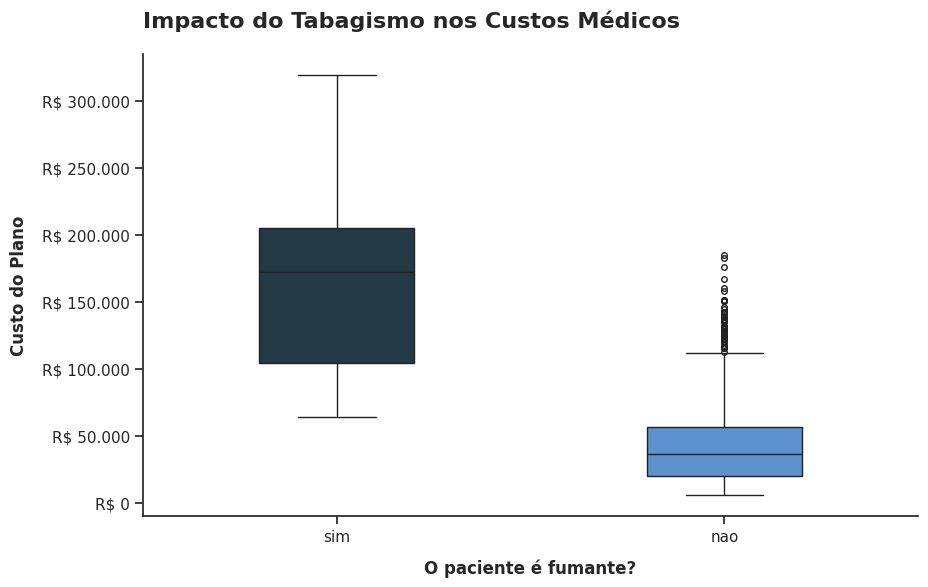

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Estilo
sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.figure(figsize=(10, 6))

# Cores
cores_corporativas = ["#1F3B4D", "#4A90E2"]
grafico = sns.boxplot(
    x='fumante',
    y='custos',
    data=dados_saude,
    palette=cores_corporativas,
    width=0.4,
    fliersize=4
)

# Alinhamento
plt.title('Impacto do Tabagismo nos Custos Médicos', fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel('O paciente é fumante?', fontsize=12, labelpad=10, fontweight='bold')
plt.ylabel('Custo do Plano', fontsize=12, labelpad=10, fontweight='bold')

# Formatando os valores do eixo Y para Moeda (R$)
formatador = ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.0f}'.replace(',', '.'))
grafico.yaxis.set_major_formatter(formatador)

plt.show()